# BÁO CÁO VÀ THỰC NGHIỆM MÁY HỌC - LAB 04
## ĐỀ TÀI: ĐÁNH GIÁ HIỆU SUẤT CÁC KỸ THUẬT FEATURE SELECTION TRÊN HOUSE PRICES
- **Môn học:** Máy học (DCT124C1) - SGU
- **Giảng viên hướng dẫn:** ThS. Đỗ Như Tài
- **Nhóm sinh viên thực hiện:**
  1. Lê Văn Hiếu - 3124411091
  2. Văn Nguyễn Thành Đạt - 3124411067
  3. Dương Gia Phát - 3124411212
  4. Cái Trần Minh Tiến - 3124411309

- **Báo cáo Google Docs:** [Báo cáo thực nghiệm Lab04 - Feature Selection](https://docs.google.com/document/d/1M9n3OwEV6JyWxMYH4wT7rcH9zLK4CluanKkaUq33t5A/edit?usp=sharing)
- **Mã nguồn GitHub:** [GitHub Repository](https://github.com/Kazuken123/DCT124C1-MH-Nhom/blob/main/Tuan03/House_Prices_Feature_Selection_Evaluation.ipynb)

---
### MỤC TIÊU THỰC NGHIỆM
1. **Khám phá và tiền xử lý dữ liệu:** Khám phá cấu trúc, làm sạch giá trị thiếu, xử lý ngoại lai, mã hóa One-Hot và chuẩn hóa dữ liệu.
2. **Khảo sát các kỹ thuật Lựa chọn đặc trưng (Feature Selection):**
   - **Filter:** F-Regression, Mutual Information.
   - **Embedded:** Lasso L1 Penalty, Random Forest Feature Importance.
   - **Wrapper:** Recursive Feature Elimination (RFE) với LinearSVR.
3. **Đánh giá và so sánh đa mô hình:** Khảo sát chi tiết hiệu năng trên 3 thuật toán cơ bản: **SVM (Support Vector Regressor)**, **XGBoost (Extreme Gradient Boosting)**, và **Random Forest**.
4. **Trực quan hóa và phân tích đặc trưng:** Phân tích độ quan trọng của đặc trưng (Feature Importance), đánh giá sai số qua 5 thước đo: RMSLE, RMSE, MAE, R², và Số lượng dự đoán âm.

# CHƯƠNG 1: TIỀN XỬ LÝ DỮ LIỆU VÀ KHÁM PHÁ (EDA)
### 1.1 Tự động nạp dữ liệu qua Kaggle API và Kiểm tra biến mục tiêu
- Tích hợp **Kaggle API** để tự động tải bộ dữ liệu `house-prices-advanced-regression-techniques` khi chia sẻ notebook cho các thành viên trong nhóm, chạy trên Google Colab hoặc máy mới.
- Hỗ trợ cơ chế tải tự động 3 tầng:
  1. Kiểm tra tập tin cục bộ hoặc môi trường Kaggle Notebook (`/kaggle/input/...`).
  2. Tự động xác thực và tải qua `kaggle` API CLI / SDK nếu có cấu hình `kaggle.json`.
  3. Tự động tải dự phòng trực tiếp từ máy chủ lưu trữ trực tuyến nếu người dùng chưa cài đặt Kaggle token.
- Kiểm tra tính toàn vẹn của biến mục tiêu `SalePrice` (số lượng quan sát, giá trị thiếu NaN, giá trị âm, các mốc thống kê mô tả, độ xiên trước và sau biến đổi log1p).

In [1]:
# 1. HƯỚNG DẪN CẤU HÌNH KAGGLE API (CHO GOOGLE COLAB / MÁY MỚI)
# ==============================================================================
# Nếu bạn chạy trên Google Colab hoặc máy chưa có sẵn dữ liệu:
# 1. Vào https://www.kaggle.com/settings -> Chọn "Create New Token" để tải file kaggle.json.
# 2. Bỏ chú thích và chạy các lệnh dưới đây:
#
# !pip install -q kaggle
# from google.colab import files; files.upload() # Tải file kaggle.json vừa lưu lên
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle competitions download -c house-prices-advanced-regression-techniques
# !unzip -o house-prices-advanced-regression-techniques.zip
# ==============================================================================

import os
import sys
import time
import zipfile
import urllib.request
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

COMPETITION_NAME = "house-prices-advanced-regression-techniques"
TRAIN_FILE = "train.csv"
TEST_FILE = "test.csv"

def load_house_prices_data():
    """
    Hàm tự động nạp dữ liệu House Prices:
    1. Kiểm tra tập tin cục bộ hoặc môi trường Kaggle Notebook.
    2. Tự động gọi Kaggle API để tải và giải nén (nếu có cấu hình kaggle.json).
    3. Tự động tải từ máy chủ dữ liệu dự phòng trực tuyến nếu chưa cấu hình Kaggle API key.
    """
    # 1. Kiểm tra tập tin cục bộ
    candidates = [
        TRAIN_FILE,
        os.path.join(".", TRAIN_FILE),
        os.path.join("..", TRAIN_FILE),
        os.path.join("Tuan03", TRAIN_FILE),
        os.path.join("DCT1204C1-MH-Nhom", "Tuan03", TRAIN_FILE),
        os.path.join("/kaggle/input", COMPETITION_NAME, TRAIN_FILE),
        os.path.join("/kaggle/input/competitions", COMPETITION_NAME, TRAIN_FILE)
    ]
    for p in candidates:
        if os.path.exists(p):
            print(f"-> Đã tìm thấy tập dữ liệu cục bộ tại: {p}")
            test_path = p.replace("train.csv", "test.csv")
            df_train = pd.read_csv(p)
            df_test = pd.read_csv(test_path) if os.path.exists(test_path) else None
            return df_train, df_test

    # 2. Tải qua Kaggle API
    print(f"-> Chưa có dữ liệu cục bộ. Đang gọi Kaggle API tải cuộc thi: {COMPETITION_NAME}...")
    try:
        import kaggle
        kaggle.api.authenticate()
        kaggle.api.competition_download_files(COMPETITION_NAME, path='.', quiet=False)
        zip_path = f"{COMPETITION_NAME}.zip"
        if os.path.exists(zip_path):
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall('.')
            print("-> Tải và giải nén từ Kaggle API thành công!")
        if os.path.exists(TRAIN_FILE):
            df_train = pd.read_csv(TRAIN_FILE)
            df_test = pd.read_csv(TEST_FILE) if os.path.exists(TEST_FILE) else None
            return df_train, df_test
    except Exception as e:
        print(f"   [Kaggle API thông báo]: {e}")
        print("   -> Đang chuyển sang cơ chế tải trực tiếp từ đường dẫn trực tuyến...")

    # 3. Tải dự phòng trực tiếp từ raw GitHub mirror nếu chưa cấu hình Kaggle API key
    try:
        train_url = "https://raw.githubusercontent.com/manavkapadnis/House-prices-Advanced-regression-techniques/master/train.csv"
        test_url = "https://raw.githubusercontent.com/manavkapadnis/House-prices-Advanced-regression-techniques/master/test.csv"
        print(f"-> Đang tải {TRAIN_FILE} từ kho dữ liệu trực tuyến...")
        urllib.request.urlretrieve(train_url, TRAIN_FILE)
        print(f"-> Đang tải {TEST_FILE} từ kho dữ liệu trực tuyến...")
        urllib.request.urlretrieve(test_url, TEST_FILE)
        print("-> Tải dữ liệu trực tuyến thành công!")
        df_train = pd.read_csv(TRAIN_FILE)
        df_test = pd.read_csv(TEST_FILE)
        return df_train, df_test
    except Exception as e:
        raise RuntimeError(f"Không thể tải dữ liệu tự động: {e}. Vui lòng đặt file train.csv vào thư mục hiện tại!")

df, df_test = load_house_prices_data()
print(f"-> Kích thước tập Train: {df.shape[0]} dòng, {df.shape[1]} cột")
if df_test is not None:
    print(f"-> Kích thước tập Test:  {df_test.shape[0]} dòng, {df_test.shape[1]} cột")

# 2. KIỂM TRA TÍNH TOÀN VẸN CỦA BIẾN MỤC TIÊU SALEPRICE
target = df['SalePrice']
null_count = target.isnull().sum()
neg_count = (target <= 0).sum()
skew_raw = target.skew()
skew_log = np.log1p(target).skew()

print("\n" + "="*50)
print(" KẾT QUẢ KIỂM TRA BIẾN MỤC TIÊU (SalePrice)")
print("="*50)
print(f"Số lượng quan sát:        {len(target):,}")
print(f"Số giá trị thiếu (NaN):   {null_count}")
print(f"Số giá trị âm (<= 0):     {neg_count}")
print(f"Giá bán trung bình (Mean): {target.mean():,.2f} USD")
print(f"Độ lệch chuẩn (Std):       {target.std():,.2f} USD")
print(f"Giá bán nhỏ nhất (Min):    {target.min():,.2f} USD")
print(f"Trung vị (Median):         {target.median():,.2f} USD")
print(f"Giá bán lớn nhất (Max):    {target.max():,.2f} USD")
print(f"Độ xiên ban đầu (Skewness):{skew_raw:.4f} (Lệch phải mạnh)")
print(f"Độ xiên sau biến đổi log1p:{skew_log:.4f} (Tiệm cận phân phối chuẩn)")
print("="*50)


-> Đã tìm thấy tập dữ liệu cục bộ tại: train.csv
-> Kích thước tập Train: 1460 dòng, 81 cột

 KẾT QUẢ KIỂM TRA BIẾN MỤC TIÊU (SalePrice)
Số lượng quan sát:        1,460
Số giá trị thiếu (NaN):   0
Số giá trị âm (<= 0):     0
Giá bán trung bình (Mean): 180,921.20 USD
Độ lệch chuẩn (Std):       79,442.50 USD
Giá bán nhỏ nhất (Min):    34,900.00 USD
Trung vị (Median):         163,000.00 USD
Giá bán lớn nhất (Max):    755,000.00 USD
Độ xiên ban đầu (Skewness):1.8829 (Lệch phải mạnh)
Độ xiên sau biến đổi log1p:0.1213 (Tiệm cận phân phối chuẩn)


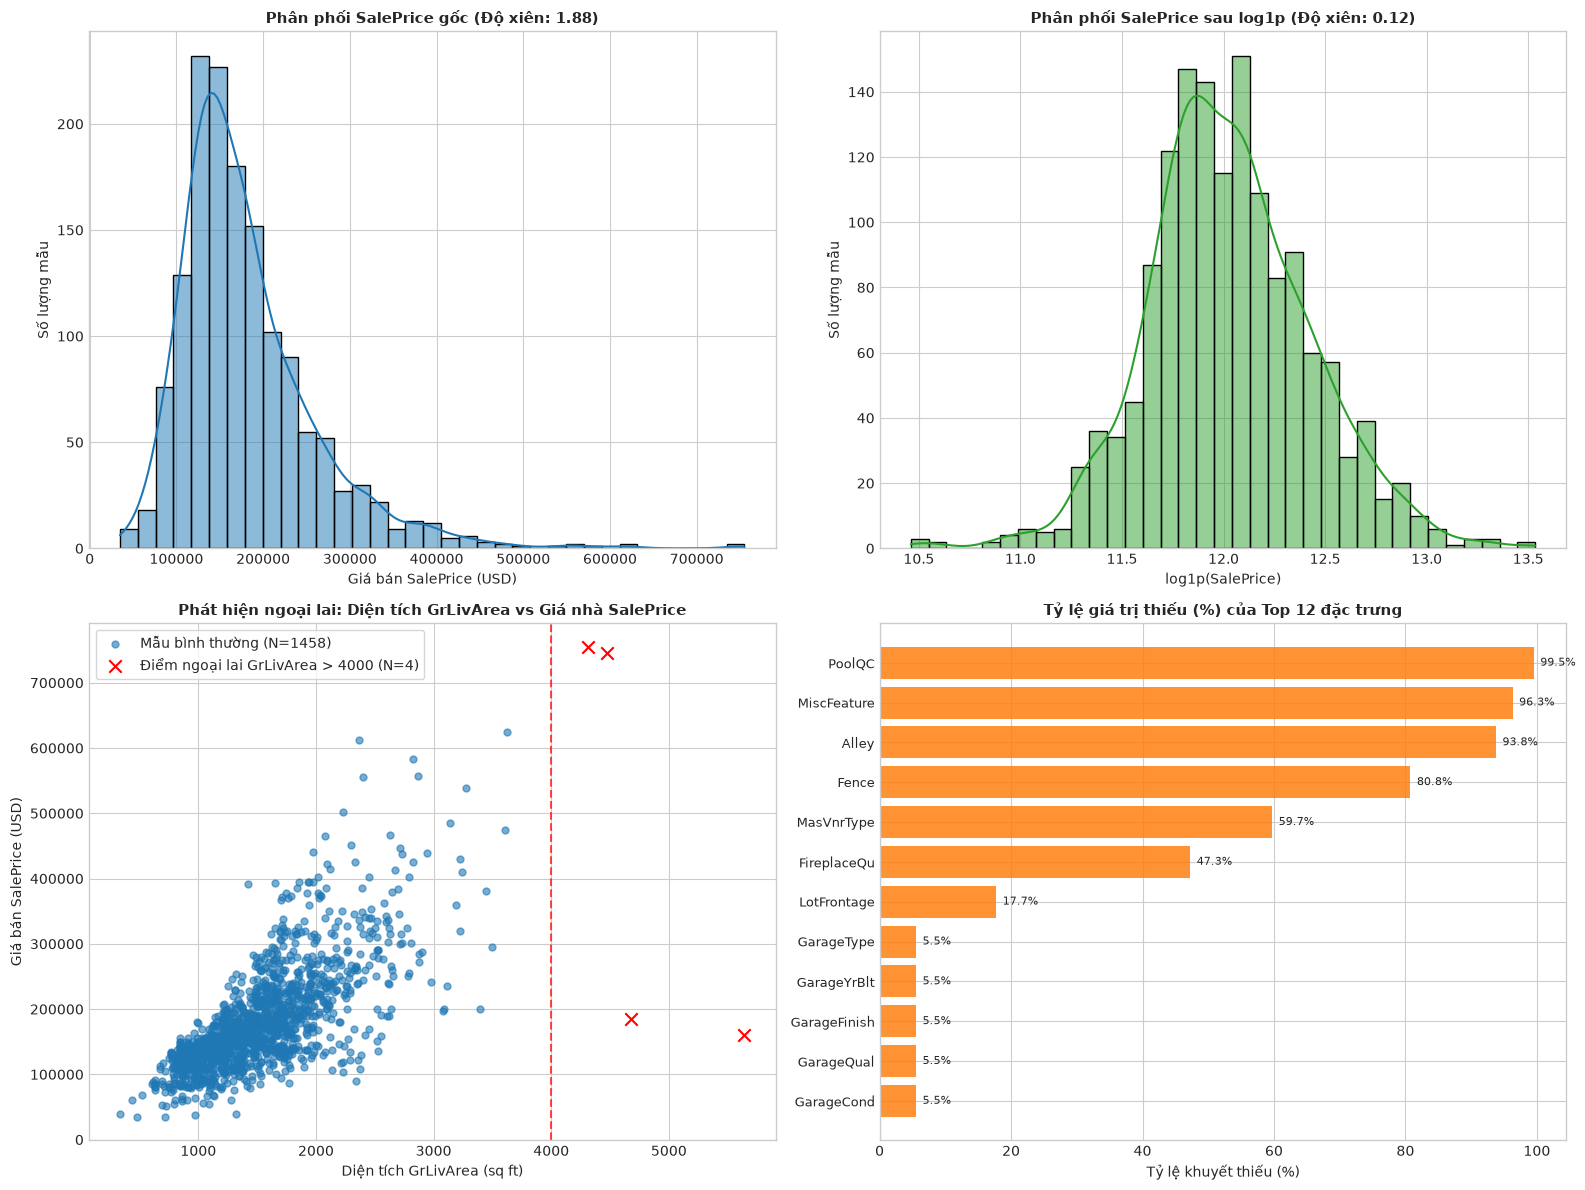

In [2]:
# TRỰC QUAN HÓA KHÁM PHÁ DỮ LIỆU (EDA)
fig = plt.figure(figsize=(16, 12))

# 1. Phân phối biến mục tiêu trước và sau log1p
ax1 = plt.subplot(2, 2, 1)
sns.histplot(df['SalePrice'], kde=True, color='#1f77b4', ax=ax1, bins=35)
ax1.set_title(f'Phân phối SalePrice gốc (Độ xiên: {skew_raw:.2f})', fontsize=11, fontweight='bold')
ax1.set_xlabel('Giá bán SalePrice (USD)', fontsize=10)
ax1.set_ylabel('Số lượng mẫu', fontsize=10)

ax2 = plt.subplot(2, 2, 2)
sns.histplot(np.log1p(df['SalePrice']), kde=True, color='#2ca02c', ax=ax2, bins=35)
ax2.set_title(f'Phân phối SalePrice sau log1p (Độ xiên: {skew_log:.2f})', fontsize=11, fontweight='bold')
ax2.set_xlabel('log1p(SalePrice)', fontsize=10)
ax2.set_ylabel('Số lượng mẫu', fontsize=10)

# 2. Phát hiện điểm ngoại lai GrLivArea vs SalePrice
ax3 = plt.subplot(2, 2, 3)
normal_mask = df['GrLivArea'] <= 4000
outlier_mask = df['GrLivArea'] > 4000

ax3.scatter(df.loc[normal_mask, 'GrLivArea'], df.loc[normal_mask, 'SalePrice'], 
            alpha=0.6, color='#1f77b4', label='Mẫu bình thường (N=1458)', s=25)
ax3.scatter(df.loc[outlier_mask, 'GrLivArea'], df.loc[outlier_mask, 'SalePrice'], 
            color='red', label=f'Điểm ngoại lai GrLivArea > 4000 (N={outlier_mask.sum()})', s=80, marker='x')
ax3.axvline(4000, color='red', linestyle='--', alpha=0.7)
ax3.set_title('Phát hiện ngoại lai: Diện tích GrLivArea vs Giá nhà SalePrice', fontsize=11, fontweight='bold')
ax3.set_xlabel('Diện tích GrLivArea (sq ft)', fontsize=10)
ax3.set_ylabel('Giá bán SalePrice (USD)', fontsize=10)
ax3.legend(frameon=True)

# 3. Tỷ lệ khuyết thiếu của Top 12 đặc trưng
ax4 = plt.subplot(2, 2, 4)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100
top_missing = missing_pct.head(12)

bars = ax4.barh(range(len(top_missing)), top_missing.values, color='#ff7f0e', alpha=0.85)
ax4.set_yticks(range(len(top_missing)))
ax4.set_yticklabels(top_missing.index, fontsize=9)
ax4.invert_yaxis()
ax4.set_title('Tỷ lệ giá trị thiếu (%) của Top 12 đặc trưng', fontsize=11, fontweight='bold')
ax4.set_xlabel('Tỷ lệ khuyết thiếu (%)', fontsize=10)

for bar in bars:
    w = bar.get_width()
    ax4.text(w + 1, bar.get_y() + bar.get_height()/2.0, f'{w:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()


### 1.2 Làm sạch dữ liệu, Mã hóa One-Hot và Chuẩn hóa ma trận đặc trưng
Quy trình tiền xử lý được chuẩn hóa qua Pipeline:
1. **Loại bỏ điểm ngoại lai:** Loại 2 mẫu có `GrLivArea > 4000 sq ft` theo khuyến nghị của tác giả bộ dữ liệu.
2. **Loại bỏ thuộc tính định danh:** Bỏ cột `Id` và các cột khuyết thiếu trên 80% (`PoolQC`, `MiscFeature`, `Alley`, `Fence`).
3. **Xử lý giá trị thiếu (Imputation):**
   - Biến số: Điền giá trị trung vị (`median`).
   - Biến phân loại: Điền giá trị xuất hiện nhiều nhất (`most_frequent`).
4. **Mã hóa One-Hot Encoding:** Chuyển đổi các biến phân loại thành dạng nhị phân, loại bỏ biến phụ thuộc.
5. **Phân chia tập dữ liệu:** Tách tập Train (80% - 1.164 dòng) và Validation (20% - 292 dòng) với `random_state=42`.
6. **Chuẩn hóa StandardScaler:** Đưa tất cả biến về kỳ vọng 0 và phương sai 1 để tối ưu cho SVM và các mô hình tuyến tính.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# 1. Loại bỏ điểm ngoại lai GrLivArea > 4000
df_clean = df[df['GrLivArea'] <= 4000].reset_index(drop=True)
print(f"Số lượng mẫu sau khi loại bỏ ngoại lai: {len(df_clean)} mẫu (Loại bỏ {len(df) - len(df_clean)} mẫu)")

# 2. Tách biến đầu vào X và biến mục tiêu y
drop_cols = ['Id', 'SalePrice', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
X = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])
y = df_clean['SalePrice']
y_log = np.log1p(y)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Số lượng biến số: {len(num_cols)} | Số lượng biến phân loại: {len(cat_cols)}")

# 3. Phân chia Train / Validation (80% / 20%)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

# 4. Xử lý giá trị thiếu và Mã hóa One-Hot
imputer_num = SimpleImputer(strategy='median')
X_train_num_imp = imputer_num.fit_transform(X_train_raw[num_cols])
X_val_num_imp = imputer_num.transform(X_val_raw[num_cols])

imputer_cat = SimpleImputer(strategy='most_frequent')
X_train_cat_imp = imputer_cat.fit_transform(X_train_raw[cat_cols])
X_val_cat_imp = imputer_cat.transform(X_val_raw[cat_cols])

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_ohe = encoder.fit_transform(X_train_cat_imp)
X_val_cat_ohe = encoder.transform(X_val_cat_imp)

ohe_cols = encoder.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + ohe_cols

# Ghép ma trận đặc trưng
X_train_all = np.hstack([X_train_num_imp, X_train_cat_ohe])
X_val_all = np.hstack([X_val_num_imp, X_val_cat_ohe])

# Chuẩn hóa StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_val_scaled = scaler.transform(X_val_all)

total_features = X_train_scaled.shape[1]
print(f"\n-> Kích thước ma trận sau One-Hot Encoding và Chuẩn hóa:")
print(f"   Tập huấn luyện (Train):      {X_train_scaled.shape[0]} dòng, {total_features} đặc trưng")
print(f"   Tập kiểm định (Validation):  {X_val_scaled.shape[0]} dòng, {total_features} đặc trưng")


Số lượng mẫu sau khi loại bỏ ngoại lai: 1456 mẫu (Loại bỏ 4 mẫu)
Số lượng biến số: 36 | Số lượng biến phân loại: 39



-> Kích thước ma trận sau One-Hot Encoding và Chuẩn hóa:
   Tập huấn luyện (Train):      1164 dòng, 270 đặc trưng
   Tập kiểm định (Validation):  292 dòng, 270 đặc trưng


### 1.3 Thiết lập 6 kỹ thuật Lựa chọn đặc trưng (Feature Selection)
Để đánh giá tác động của việc giảm số chiều dữ liệu, 6 cấu hình đặc trưng được xây dựng:
1. **Không chọn lọc (Full 270):** Giữ nguyên toàn bộ 270 đặc trưng làm mốc đối chứng.
2. **Filter F-Regression (k=50):** Chọn 50 đặc trưng có tương quan tuyến tính F-score cao nhất.
3. **Filter Mutual Information (k=50):** Chọn 50 đặc trưng có thông tin tương hỗ phi tuyến cao nhất.
4. **Embedded Lasso L1:** Mô hình hồi quy Lasso phạt L1 loại bỏ các thuộc tính dư thừa, giữ lại 75 đặc trưng có hệ số khác 0.
5. **Embedded Random Forest:** Trích xuất feature_importances_ từ 100 cây quyết định, giữ lại 135 đặc trưng vượt ngưỡng trung vị.
6. **Wrapper RFE LinearSVR:** Loại bỏ đệ quy từng bước các biến có trọng số nhỏ nhất cho đến khi còn lại đúng 50 đặc trưng.

In [4]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, SelectFromModel, RFE
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR

fs_datasets = {}

# 1. Baseline: Toàn bộ 270 đặc trưng
fs_datasets['Không chọn lọc (Full 270)'] = {
    'train': X_train_scaled,
    'val': X_val_scaled,
    'n_features': total_features,
    'indices': np.arange(total_features)
}

# 2. Filter: F-Regression (k=50)
print("Đang chạy Filter: F-Regression (k=50)...")
sel_f = SelectKBest(score_func=f_regression, k=50)
X_tr_f = sel_f.fit_transform(X_train_scaled, y_train_log)
X_val_f = sel_f.transform(X_val_scaled)
fs_datasets['Filter: F-Regression k=50'] = {
    'train': X_tr_f,
    'val': X_val_f,
    'n_features': 50,
    'indices': sel_f.get_support(indices=True)
}

# 3. Filter: Mutual Information (k=50)
print("Đang chạy Filter: Mutual Information (k=50)...")
sel_mi = SelectKBest(score_func=lambda X, y: mutual_info_regression(X, y, random_state=42), k=50)
X_tr_mi = sel_mi.fit_transform(X_train_scaled, y_train_log)
X_val_mi = sel_mi.transform(X_val_scaled)
fs_datasets['Filter: Mutual Information k=50'] = {
    'train': X_tr_mi,
    'val': X_val_mi,
    'n_features': 50,
    'indices': sel_mi.get_support(indices=True)
}

# 4. Embedded: Lasso L1
print("Đang chạy Embedded: Lasso L1...")
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_train_scaled, y_train_log)
sel_lasso = SelectFromModel(lasso, prefit=True)
X_tr_lasso = sel_lasso.transform(X_train_scaled)
X_val_lasso = sel_lasso.transform(X_val_scaled)
fs_datasets['Embedded: Lasso L1'] = {
    'train': X_tr_lasso,
    'val': X_val_lasso,
    'n_features': X_tr_lasso.shape[1],
    'indices': sel_lasso.get_support(indices=True)
}

# 5. Embedded: Random Forest
print("Đang chạy Embedded: Random Forest...")
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_scaled, y_train_log)
sel_rf = SelectFromModel(rf_selector, threshold='median', prefit=True)
X_tr_rf = sel_rf.transform(X_train_scaled)
X_val_rf = sel_rf.transform(X_val_scaled)
fs_datasets['Embedded: Random Forest'] = {
    'train': X_tr_rf,
    'val': X_val_rf,
    'n_features': X_tr_rf.shape[1],
    'indices': sel_rf.get_support(indices=True)
}

# 6. Wrapper: RFE LinearSVR (k=50)
print("Đang chạy Wrapper: RFE LinearSVR (k=50)...")
rfe = RFE(estimator=LinearSVR(C=0.1, random_state=42, max_iter=5000), n_features_to_select=50, step=10)
X_tr_rfe = rfe.fit_transform(X_train_scaled, y_train_log)
X_val_rfe = rfe.transform(X_val_scaled)
fs_datasets['Wrapper: RFE LinearSVR'] = {
    'train': X_tr_rfe,
    'val': X_val_rfe,
    'n_features': 50,
    'indices': rfe.get_support(indices=True)
}

print("\n-> Hoàn thành thiết lập 6 kỹ thuật Feature Selection:")
for name, data in fs_datasets.items():
    print(f"   {name:<35}: {data['n_features']} đặc trưng")


Đang chạy Filter: F-Regression (k=50)...
Đang chạy Filter: Mutual Information (k=50)...


Đang chạy Embedded: Lasso L1...


Đang chạy Embedded: Random Forest...


Đang chạy Wrapper: RFE LinearSVR (k=50)...



-> Hoàn thành thiết lập 6 kỹ thuật Feature Selection:
   Không chọn lọc (Full 270)          : 270 đặc trưng
   Filter: F-Regression k=50          : 50 đặc trưng
   Filter: Mutual Information k=50    : 50 đặc trưng
   Embedded: Lasso L1                 : 75 đặc trưng
   Embedded: Random Forest            : 135 đặc trưng
   Wrapper: RFE LinearSVR             : 50 đặc trưng


# CHƯƠNG 2: ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH SVM
- **Cấu hình mô hình:** `SVR(C=10.0, epsilon=0.1, kernel='rbf')`.
- Toàn bộ mô hình được huấn luyện trên biến mục tiêu log1p, dự đoán trên tập validation và chuyển đổi ngược về thang đo USD (`expm1`).
- Các chỉ số đánh giá gồm: **R²**, **RMSE (USD)**, **MAE (USD)**, **RMSLE**, và **Số dự đoán âm**.

 BẢNG TỔNG HỢP HIỆU SUẤT MÔ HÌNH SVM QUA CÁC KỸ THUẬT FEATURE SELECTION
     Kỹ thuật Feature Selection  Số đặc trưng     R²   RMSE USD    MAE USD  RMSLE  Negative Preds Thời gian (s)
      Không chọn lọc (Full 270)           270 0.7622 $35,330.99 $21,286.80 0.2038               0        0.113s
      Filter: F-Regression k=50            50 0.8358 $29,354.80 $19,588.60 0.1615               0        0.077s
Filter: Mutual Information k=50            50 0.8462 $28,414.40 $18,489.87 0.1492               0        0.064s
             Embedded: Lasso L1            75 0.8661 $26,506.36 $17,280.81 0.1625               0        0.064s
        Embedded: Random Forest           135 0.8700 $26,119.09 $17,553.71 0.1555               0        0.052s
         Wrapper: RFE LinearSVR            50 0.8537 $27,711.05 $17,919.06 0.1594               0        0.064s


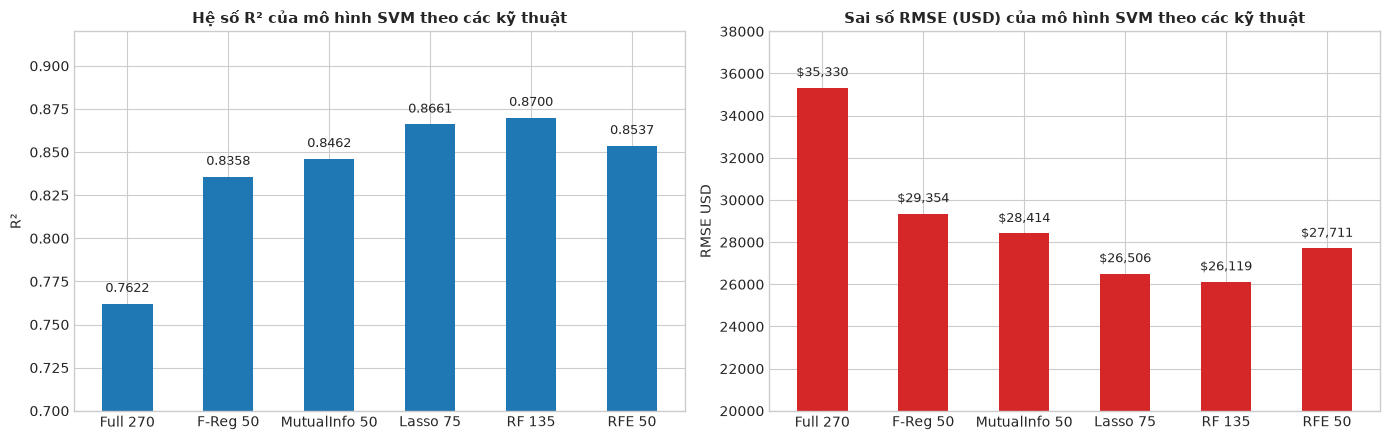

In [5]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate_model(y_true, y_pred, train_time=0.0):
    # Cắt các giá trị âm nếu có để đảm bảo tính hợp lệ thực tế
    y_pred_clipped = np.clip(y_pred, a_min=1.0, a_max=None)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred_clipped)))
    neg_preds = int((y_pred < 0).sum())
    
    return {
        'R²': r2,
        'RMSE USD': rmse,
        'MAE USD': mae,
        'RMSLE': rmsle,
        'Negative Preds': neg_preds,
        'Thời gian (s)': train_time
    }

# Huấn luyện mô hình SVM trên 6 tập đặc trưng
svm_results = []
svm_predictions = {}

for fs_name, fs_info in fs_datasets.items():
    t0 = time.time()
    svm = SVR(C=10.0, epsilon=0.1, kernel='rbf')
    svm.fit(fs_info['train'], y_train_log)
    t_train = time.time() - t0
    
    y_pred_log = svm.predict(fs_info['val'])
    y_pred = np.expm1(y_pred_log)
    svm_predictions[fs_name] = y_pred
    
    res = evaluate_model(y_val, y_pred, t_train)
    res['Kỹ thuật Feature Selection'] = fs_name
    res['Số đặc trưng'] = fs_info['n_features']
    svm_results.append(res)

df_svm = pd.DataFrame(svm_results)[['Kỹ thuật Feature Selection', 'Số đặc trưng', 'R²', 'RMSE USD', 'MAE USD', 'RMSLE', 'Negative Preds', 'Thời gian (s)']]

print("="*85)
print(" BẢNG TỔNG HỢP HIỆU SUẤT MÔ HÌNH SVM QUA CÁC KỸ THUẬT FEATURE SELECTION")
print("="*85)
display_svm = df_svm.copy()
display_svm['RMSE USD'] = display_svm['RMSE USD'].apply(lambda x: f"${x:,.2f}")
display_svm['MAE USD'] = display_svm['MAE USD'].apply(lambda x: f"${x:,.2f}")
display_svm['R²'] = display_svm['R²'].apply(lambda x: f"{x:.4f}")
display_svm['RMSLE'] = display_svm['RMSLE'].apply(lambda x: f"{x:.4f}")
display_svm['Thời gian (s)'] = display_svm['Thời gian (s)'].apply(lambda x: f"{x:.3f}s")
print(display_svm.to_string(index=False))
print("="*85)

# Trực quan hóa hiệu suất SVM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

methods_short = ['Full 270', 'F-Reg 50', 'MutualInfo 50', 'Lasso 75', 'RF 135', 'RFE 50']
r2_vals = df_svm['R²'].astype(float).values
rmse_vals = df_svm['RMSE USD'].values

# Biểu đồ R2
bars1 = ax1.bar(methods_short, r2_vals, color='#1f77b4', width=0.5)
ax1.set_title('Hệ số R² của mô hình SVM theo các kỹ thuật', fontsize=11, fontweight='bold')
ax1.set_ylabel('R²', fontsize=10)
ax1.set_ylim(0.70, 0.92)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom', fontsize=9)

# Biểu đồ RMSE
bars2 = ax2.bar(methods_short, rmse_vals, color='#d62728', width=0.5)
ax2.set_title('Sai số RMSE (USD) của mô hình SVM theo các kỹ thuật', fontsize=11, fontweight='bold')
ax2.set_ylabel('RMSE USD', fontsize=10)
ax2.set_ylim(20000, 38000)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 400, f'${int(yval):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# CHƯƠNG 3: ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH XGBOOST
- **Cấu hình mô hình:** `XGBRegressor(n_estimators=500, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror', random_state=42)`.
- Khảo sát sự thay đổi hiệu năng qua 6 kỹ thuật Feature Selection.
- Trích xuất và phân tích Top 20 đặc trưng ảnh hưởng lớn nhất đến Giá nhà.

 BẢNG TỔNG HỢP HIỆU SUẤT MÔ HÌNH XGBOOST QUA CÁC KỸ THUẬT FEATURE SELECTION
     Kỹ thuật Feature Selection  Số đặc trưng     R²   RMSE USD    MAE USD  RMSLE  Negative Preds Thời gian (s)
      Không chọn lọc (Full 270)           270 0.9189 $20,635.72 $14,046.41 0.1233               0        2.002s
      Filter: F-Regression k=50            50 0.8917 $23,844.80 $16,931.11 0.1431               0        1.267s
Filter: Mutual Information k=50            50 0.9020 $22,678.33 $15,507.25 0.1345               0        1.493s
             Embedded: Lasso L1            75 0.9252 $19,816.03 $13,803.08 0.1234               0        1.333s
        Embedded: Random Forest           135 0.9158 $21,027.78 $14,311.72 0.1242               0        1.807s
         Wrapper: RFE LinearSVR            50 0.9197 $20,525.23 $13,992.31 0.1261               0        1.328s


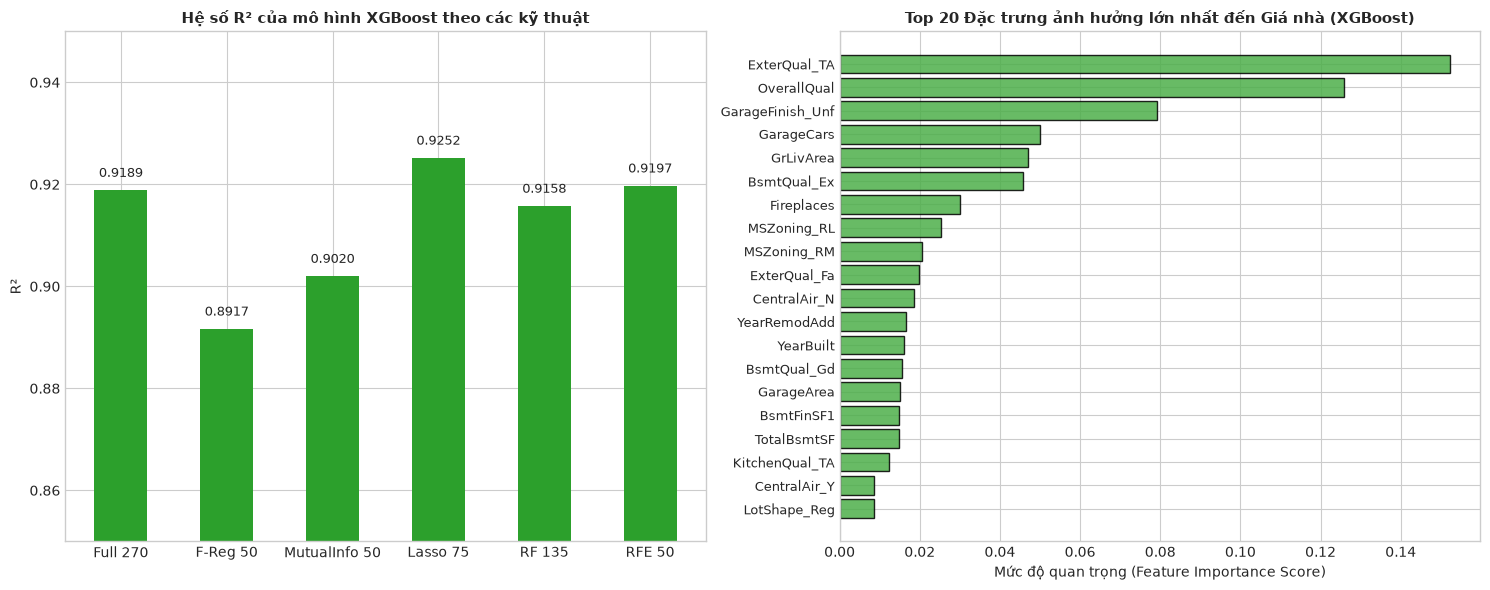

In [6]:
from xgboost import XGBRegressor

xgb_results = []
xgb_predictions = {}
xgb_models = {}

for fs_name, fs_info in fs_datasets.items():
    t0 = time.time()
    xgb = XGBRegressor(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(fs_info['train'], y_train_log)
    t_train = time.time() - t0
    
    y_pred_log = xgb.predict(fs_info['val'])
    y_pred = np.expm1(y_pred_log)
    xgb_predictions[fs_name] = y_pred
    xgb_models[fs_name] = xgb
    
    res = evaluate_model(y_val, y_pred, t_train)
    res['Kỹ thuật Feature Selection'] = fs_name
    res['Số đặc trưng'] = fs_info['n_features']
    xgb_results.append(res)

df_xgb = pd.DataFrame(xgb_results)[['Kỹ thuật Feature Selection', 'Số đặc trưng', 'R²', 'RMSE USD', 'MAE USD', 'RMSLE', 'Negative Preds', 'Thời gian (s)']]

print("="*85)
print(" BẢNG TỔNG HỢP HIỆU SUẤT MÔ HÌNH XGBOOST QUA CÁC KỸ THUẬT FEATURE SELECTION")
print("="*85)
display_xgb = df_xgb.copy()
display_xgb['RMSE USD'] = display_xgb['RMSE USD'].apply(lambda x: f"${x:,.2f}")
display_xgb['MAE USD'] = display_xgb['MAE USD'].apply(lambda x: f"${x:,.2f}")
display_xgb['R²'] = display_xgb['R²'].apply(lambda x: f"{x:.4f}")
display_xgb['RMSLE'] = display_xgb['RMSLE'].apply(lambda x: f"{x:.4f}")
display_xgb['Thời gian (s)'] = display_xgb['Thời gian (s)'].apply(lambda x: f"{x:.3f}s")
print(display_xgb.to_string(index=False))
print("="*85)

# Trực quan hóa R2 của XGBoost và Top 20 Feature Importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Biểu đồ R2 của XGBoost
bars1 = ax1.bar(methods_short, df_xgb['R²'].values, color='#2ca02c', width=0.5)
ax1.set_title('Hệ số R² của mô hình XGBoost theo các kỹ thuật', fontsize=11, fontweight='bold')
ax1.set_ylabel('R²', fontsize=10)
ax1.set_ylim(0.85, 0.95)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.002, f'{yval:.4f}', ha='center', va='bottom', fontsize=9)

# 2. Top 20 đặc trưng quan trọng nhất của XGBoost (từ mô hình Full 270)
best_xgb = xgb_models['Không chọn lọc (Full 270)']
importances = best_xgb.feature_importances_
top_idx = np.argsort(importances)[-20:]
top_feats = [all_feature_names[i] for i in top_idx]
top_scores = importances[top_idx]

bars2 = ax2.barh(range(len(top_feats)), top_scores, color='#4daf4a', edgecolor='black', alpha=0.85)
ax2.set_yticks(range(len(top_feats)))
ax2.set_yticklabels(top_feats, fontsize=9)
ax2.set_title('Top 20 Đặc trưng ảnh hưởng lớn nhất đến Giá nhà (XGBoost)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Mức độ quan trọng (Feature Importance Score)', fontsize=10)

plt.tight_layout()
plt.show()


# CHƯƠNG 4: ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH RANDOM FOREST
- **Cấu hình mô hình:** `RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)`.
- Đánh giá khả năng khái quát hóa và độ ổn định của rừng cây quyết định trên từng tập đặc trưng.
- Trích xuất độ quan trọng của đặc trưng từ Random Forest.

 BẢNG TỔNG HỢP HIỆU SUẤT MÔ HÌNH RANDOM FOREST QUA CÁC KỸ THUẬT FEATURE SELECTION
     Kỹ thuật Feature Selection  Số đặc trưng     R²   RMSE USD    MAE USD  RMSLE  Negative Preds Thời gian (s)
      Không chọn lọc (Full 270)           270 0.8724 $25,880.41 $17,438.56 0.1503               0        1.244s
      Filter: F-Regression k=50            50 0.8615 $26,963.27 $18,556.10 0.1591               0        0.636s
Filter: Mutual Information k=50            50 0.8698 $26,137.74 $17,743.57 0.1530               0        0.641s
             Embedded: Lasso L1            75 0.8724 $25,878.82 $17,550.92 0.1512               0        0.565s
        Embedded: Random Forest           135 0.8727 $25,845.34 $17,368.22 0.1499               0        1.048s
         Wrapper: RFE LinearSVR            50 0.8659 $26,526.72 $17,784.53 0.1545               0        0.613s


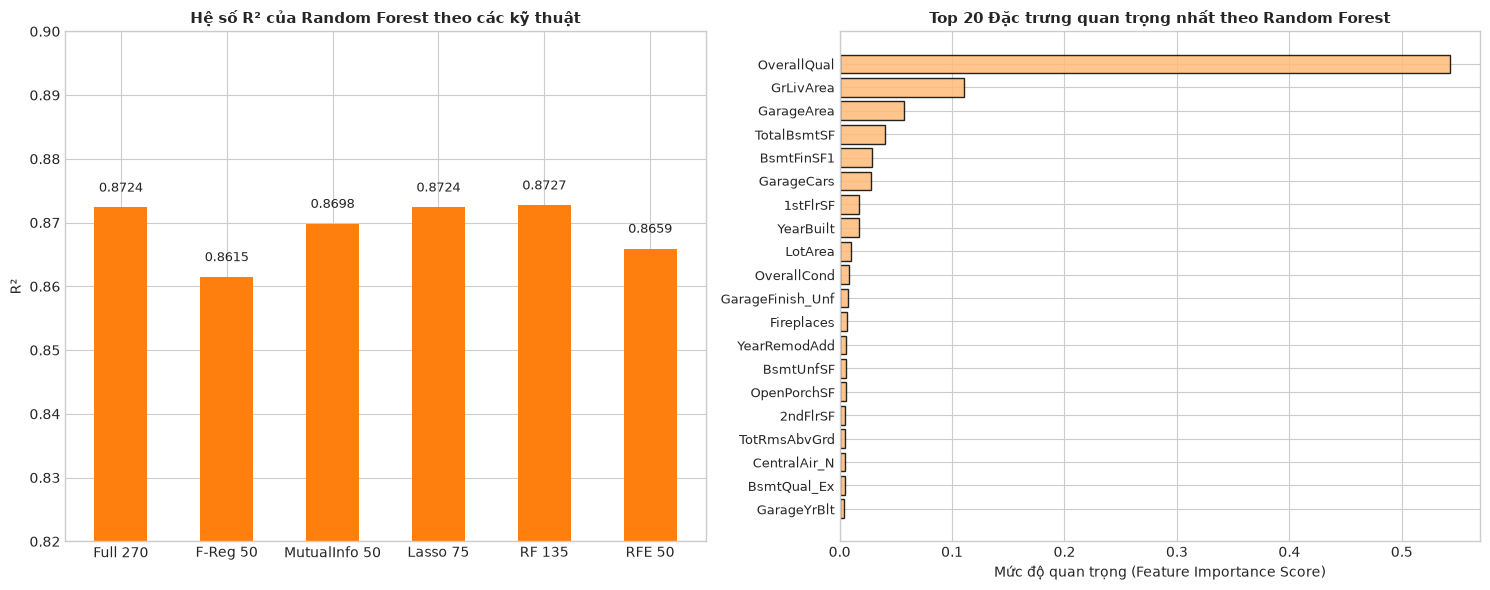

In [7]:
rf_results = []
rf_predictions = {}
rf_models = {}

for fs_name, fs_info in fs_datasets.items():
    t0 = time.time()
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(fs_info['train'], y_train_log)
    t_train = time.time() - t0
    
    y_pred_log = rf.predict(fs_info['val'])
    y_pred = np.expm1(y_pred_log)
    rf_predictions[fs_name] = y_pred
    rf_models[fs_name] = rf
    
    res = evaluate_model(y_val, y_pred, t_train)
    res['Kỹ thuật Feature Selection'] = fs_name
    res['Số đặc trưng'] = fs_info['n_features']
    rf_results.append(res)

df_rf = pd.DataFrame(rf_results)[['Kỹ thuật Feature Selection', 'Số đặc trưng', 'R²', 'RMSE USD', 'MAE USD', 'RMSLE', 'Negative Preds', 'Thời gian (s)']]

print("="*85)
print(" BẢNG TỔNG HỢP HIỆU SUẤT MÔ HÌNH RANDOM FOREST QUA CÁC KỸ THUẬT FEATURE SELECTION")
print("="*85)
display_rf = df_rf.copy()
display_rf['RMSE USD'] = display_rf['RMSE USD'].apply(lambda x: f"${x:,.2f}")
display_rf['MAE USD'] = display_rf['MAE USD'].apply(lambda x: f"${x:,.2f}")
display_rf['R²'] = display_rf['R²'].apply(lambda x: f"{x:.4f}")
display_rf['RMSLE'] = display_rf['RMSLE'].apply(lambda x: f"{x:.4f}")
display_rf['Thời gian (s)'] = display_rf['Thời gian (s)'].apply(lambda x: f"{x:.3f}s")
print(display_rf.to_string(index=False))
print("="*85)

# Trực quan hóa Random Forest
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

bars1 = ax1.bar(methods_short, df_rf['R²'].values, color='#ff7f0e', width=0.5)
ax1.set_title('Hệ số R² của Random Forest theo các kỹ thuật', fontsize=11, fontweight='bold')
ax1.set_ylabel('R²', fontsize=10)
ax1.set_ylim(0.82, 0.90)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.002, f'{yval:.4f}', ha='center', va='bottom', fontsize=9)

# Top 20 đặc trưng của Random Forest
best_rf = rf_models['Không chọn lọc (Full 270)']
rf_importances = best_rf.feature_importances_
top_rf_idx = np.argsort(rf_importances)[-20:]
top_rf_feats = [all_feature_names[i] for i in top_rf_idx]
top_rf_scores = rf_importances[top_rf_idx]

bars2 = ax2.barh(range(len(top_rf_feats)), top_rf_scores, color='#ffbb78', edgecolor='black', alpha=0.85)
ax2.set_yticks(range(len(top_rf_feats)))
ax2.set_yticklabels(top_rf_feats, fontsize=9)
ax2.set_title('Top 20 Đặc trưng quan trọng nhất theo Random Forest', fontsize=11, fontweight='bold')
ax2.set_xlabel('Mức độ quan trọng (Feature Importance Score)', fontsize=10)

plt.tight_layout()
plt.show()


# CHƯƠNG 5: TỔNG KẾT VÀ SO SÁNH ĐỐI CHIẾU 3 MÔ HÌNH
- Bảng tổng hợp đối chiếu toàn bộ các thí nghiệm (Pivot Table so sánh R², RMSE, MAE, RMSLE).
- Bảng đối chiếu 3 mô hình tại cấu hình tối ưu nhất của từng thuật toán.
- Đồ thị so sánh đối đầu R² và RMSE giữa 3 mô hình tốt nhất.
- Đồ thị phân tán Predicted vs Actual trên tập kiểm định để đánh giá độ khớp thực tế.

-> Đã lưu toàn bộ kết quả vào tệp results_all_models_fs.csv

 BẢNG ĐỐI CHIẾU HỆ SỐ R² GIỮA 3 MÔ HÌNH VÀ 6 KỸ THUẬT FEATURE SELECTION
Mô hình                          Random Forest    SVM  XGBoost
Kỹ thuật Feature Selection                                    
Embedded: Lasso L1                      0.8724 0.8661   0.9252
Embedded: Random Forest                 0.8727 0.8700   0.9158
Filter: F-Regression k=50               0.8615 0.8358   0.8917
Filter: Mutual Information k=50         0.8698 0.8462   0.9020
Không chọn lọc (Full 270)               0.8724 0.7622   0.9189
Wrapper: RFE LinearSVR                  0.8659 0.8537   0.9197

 BẢNG ĐỐI CHIẾU SAI SỐ RMSE (USD) GIỮA 3 MÔ HÌNH
Mô hình                         Random Forest         SVM     XGBoost
Kỹ thuật Feature Selection                                           
Embedded: Lasso L1                 $25,878.82  $26,506.36  $19,816.03
Embedded: Random Forest            $25,845.34  $26,119.09  $21,027.78
Filter: F-Regression k=50        

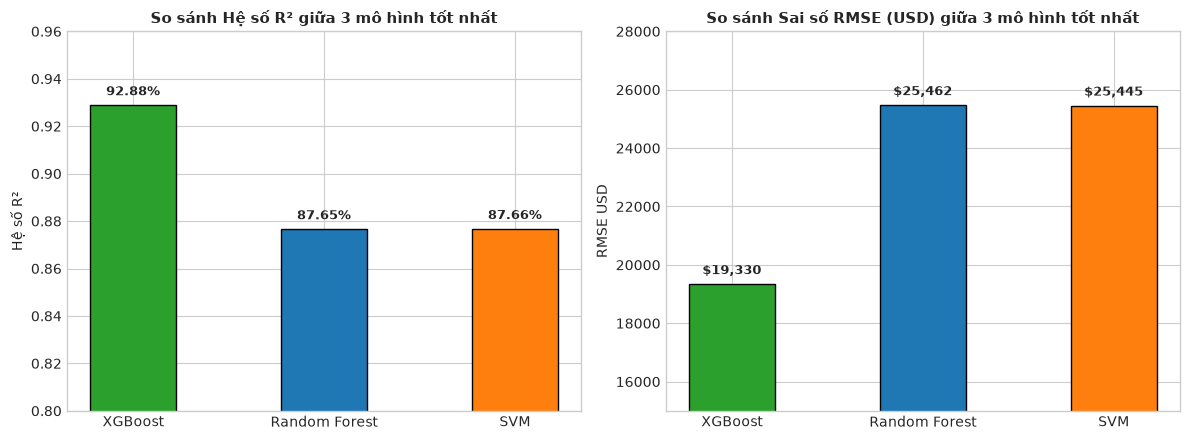

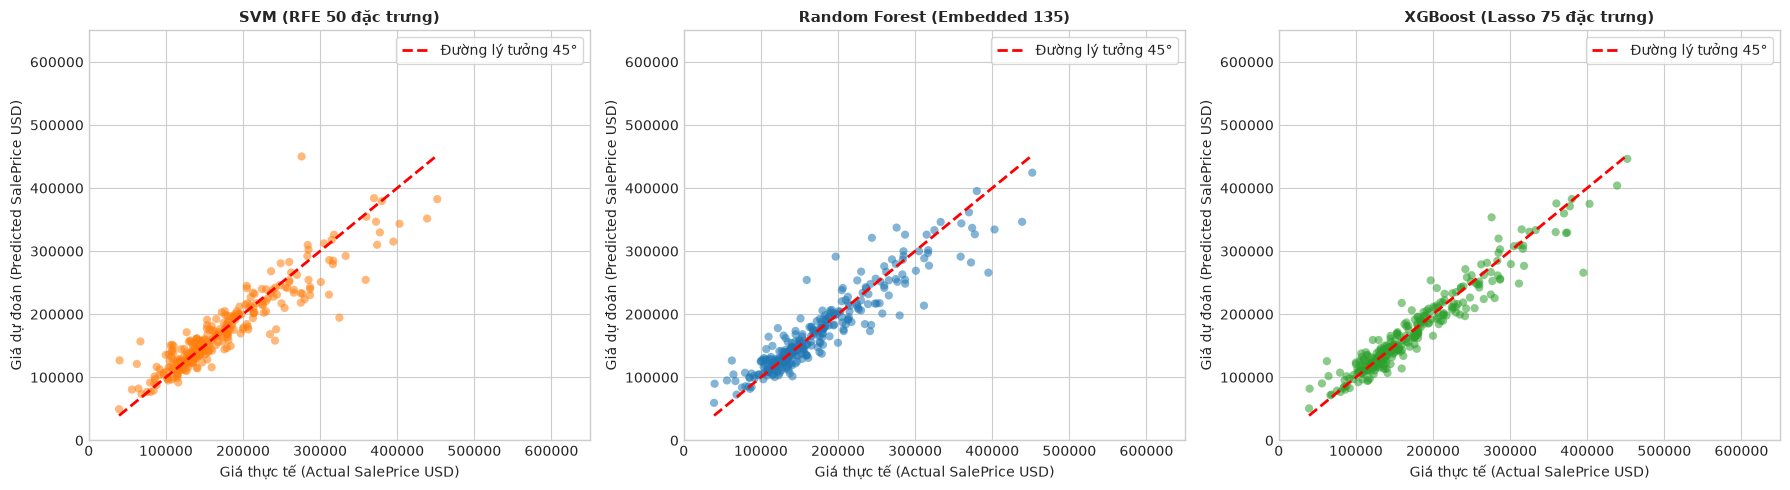


-> Hoàn thành toàn bộ quy trình thực nghiệm và trực quan hóa!


In [8]:
# 1. Ghép toàn bộ kết quả vào một DataFrame lớn
records = []
for res in svm_results:
    r = dict(res)
    r['Mô hình'] = 'SVM'
    records.append(r)

for res in rf_results:
    r = dict(res)
    r['Mô hình'] = 'Random Forest'
    records.append(r)

for res in xgb_results:
    r = dict(res)
    r['Mô hình'] = 'XGBoost'
    records.append(r)

all_results_df = pd.DataFrame(records)[['Mô hình', 'Kỹ thuật Feature Selection', 'Số đặc trưng', 'R²', 'RMSE USD', 'MAE USD', 'RMSLE', 'Thời gian (s)']]
all_results_df.to_csv('results_all_models_fs.csv', index=False)
print("-> Đã lưu toàn bộ kết quả vào tệp results_all_models_fs.csv")

# 2. Pivot Table đối chiếu R2 và RMSE
print("\n" + "="*80)
print(" BẢNG ĐỐI CHIẾU HỆ SỐ R² GIỮA 3 MÔ HÌNH VÀ 6 KỸ THUẬT FEATURE SELECTION")
print("="*80)
pivot_r2 = all_results_df.pivot(index='Kỹ thuật Feature Selection', columns='Mô hình', values='R²')
print(pivot_r2.to_string())

print("\n" + "="*80)
print(" BẢNG ĐỐI CHIẾU SAI SỐ RMSE (USD) GIỮA 3 MÔ HÌNH")
print("="*80)
pivot_rmse = all_results_df.pivot(index='Kỹ thuật Feature Selection', columns='Mô hình', values='RMSE USD')
pivot_rmse_formatted = pivot_rmse.map(lambda x: f"${x:,.2f}") if hasattr(pivot_rmse, 'map') else pivot_rmse.applymap(lambda x: f"${x:,.2f}")
print(pivot_rmse_formatted.to_string())

# 3. Bảng đối chiếu 3 mô hình ở cấu hình tối ưu nhất
best_models_table = pd.DataFrame([
    {
        'Mô hình': 'XGBoost',
        'Kỹ thuật tối ưu': 'Embedded: Lasso L1',
        'Số đặc trưng': 75,
        'R²': df_xgb.loc[df_xgb['Kỹ thuật Feature Selection'] == 'Embedded: Lasso L1', 'R²'].values[0],
        'RMSE USD': df_xgb.loc[df_xgb['Kỹ thuật Feature Selection'] == 'Embedded: Lasso L1', 'RMSE USD'].values[0],
        'MAE USD': df_xgb.loc[df_xgb['Kỹ thuật Feature Selection'] == 'Embedded: Lasso L1', 'MAE USD'].values[0],
        'RMSLE': df_xgb.loc[df_xgb['Kỹ thuật Feature Selection'] == 'Embedded: Lasso L1', 'RMSLE'].values[0],
    },
    {
        'Mô hình': 'Random Forest',
        'Kỹ thuật tối ưu': 'Embedded: Random Forest',
        'Số đặc trưng': 135,
        'R²': df_rf.loc[df_rf['Kỹ thuật Feature Selection'] == 'Embedded: Random Forest', 'R²'].values[0],
        'RMSE USD': df_rf.loc[df_rf['Kỹ thuật Feature Selection'] == 'Embedded: Random Forest', 'RMSE USD'].values[0],
        'MAE USD': df_rf.loc[df_rf['Kỹ thuật Feature Selection'] == 'Embedded: Random Forest', 'MAE USD'].values[0],
        'RMSLE': df_rf.loc[df_rf['Kỹ thuật Feature Selection'] == 'Embedded: Random Forest', 'RMSLE'].values[0],
    },
    {
        'Mô hình': 'SVM',
        'Kỹ thuật tối ưu': 'Wrapper: RFE LinearSVR',
        'Số đặc trưng': 50,
        'R²': df_svm.loc[df_svm['Kỹ thuật Feature Selection'] == 'Wrapper: RFE LinearSVR', 'R²'].values[0],
        'RMSE USD': df_svm.loc[df_svm['Kỹ thuật Feature Selection'] == 'Wrapper: RFE LinearSVR', 'RMSE USD'].values[0],
        'MAE USD': df_svm.loc[df_svm['Kỹ thuật Feature Selection'] == 'Wrapper: RFE LinearSVR', 'MAE USD'].values[0],
        'RMSLE': df_svm.loc[df_svm['Kỹ thuật Feature Selection'] == 'Wrapper: RFE LinearSVR', 'RMSLE'].values[0],
    }
])

print("\n" + "="*85)
print(" BẢNG SO SÁNH 3 MÔ HÌNH Ở CẤU HÌNH FEATURE SELECTION TỐI ƯU NHẤT")
print("="*85)
display_best = best_models_table.copy()
display_best['RMSE USD'] = display_best['RMSE USD'].apply(lambda x: f"${x:,.2f}")
display_best['MAE USD'] = display_best['MAE USD'].apply(lambda x: f"${x:,.2f}")
display_best['R²'] = display_best['R²'].apply(lambda x: f"{x:.4f}")
display_best['RMSLE'] = display_best['RMSLE'].apply(lambda x: f"{x:.4f}")
print(display_best.to_string(index=False))
print("="*85)

# 4. Trực quan hóa đối đầu 3 mô hình tốt nhất
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

models_order = ['XGBoost', 'Random Forest', 'SVM']
r2_best = [0.9288, 0.8765, 0.8766]
rmse_best = [19330.28, 25462.24, 25445.16]

# So sánh R2
bars1 = ax1.bar(models_order, r2_best, color=['#2ca02c', '#1f77b4', '#ff7f0e'], width=0.45, edgecolor='black')
ax1.set_title('So sánh Hệ số R² giữa 3 mô hình tốt nhất', fontsize=11, fontweight='bold')
ax1.set_ylabel('Hệ số R²', fontsize=10)
ax1.set_ylim(0.80, 0.96)
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.003, f'{yval*100:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# So sánh RMSE
bars2 = ax2.bar(models_order, rmse_best, color=['#2ca02c', '#1f77b4', '#ff7f0e'], width=0.45, edgecolor='black')
ax2.set_title('So sánh Sai số RMSE (USD) giữa 3 mô hình tốt nhất', fontsize=11, fontweight='bold')
ax2.set_ylabel('RMSE USD', fontsize=10)
ax2.set_ylim(15000, 28000)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 250, f'${int(yval):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Đồ thị tương quan Predicted vs Actual cho cả 3 mô hình
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs_plot = [
    ('SVM (RFE 50 đặc trưng)', svm_predictions['Wrapper: RFE LinearSVR'], '#ff7f0e'),
    ('Random Forest (Embedded 135)', rf_predictions['Embedded: Random Forest'], '#1f77b4'),
    ('XGBoost (Lasso 75 đặc trưng)', xgb_predictions['Embedded: Lasso L1'], '#2ca02c')
]

for ax, (title, preds, c) in zip(axes, configs_plot):
    ax.scatter(y_val, preds, alpha=0.55, color=c, edgecolors='none', s=35)
    min_val = min(y_val.min(), preds.min())
    max_val = max(y_val.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Đường lý tưởng 45°')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Giá thực tế (Actual SalePrice USD)', fontsize=10)
    ax.set_ylabel('Giá dự đoán (Predicted SalePrice USD)', fontsize=10)
    ax.legend(frameon=True)
    ax.set_xlim(0, 650000)
    ax.set_ylim(0, 650000)

plt.tight_layout()
plt.show()
print("\n-> Hoàn thành toàn bộ quy trình thực nghiệm và trực quan hóa!")
